# **Project Name**    -
Yes Bank Stock Price Prediction using Machine Learning

##### **Project Type**    - Regression
##### **Contribution**    - Individual
##### **Team Members**    - Not Applicable(Individual Project)

# **Project Summary -**
The Yes Bank Stock Price Prediction using Machine Learning project focuses on developing a regression model to predict the closing stock price of Yes Bank using historical stock market data. After completing data preprocessing and exploratory data analysis, the cleaned dataset was used to train and evaluate machine learning models capable of making accurate predictions based on historical price patterns.

The dataset contains important stock market attributes such as Open, High, Low, and Close prices. Appropriate feature selection and preprocessing techniques were applied before dividing the dataset into training and testing sets using an 80:20 ratio. This ensured that the model was trained on historical data while its performance was evaluated on unseen data.

Multiple regression algorithms were implemented to predict the closing stock price. A Linear Regression model was initially developed as a baseline model. To improve prediction accuracy and capture more complex relationships within the data, a Random Forest Regressor was also implemented. Hyperparameter tuning was performed using GridSearchCV to determine the optimal model parameters and improve the overall predictive performance.

The performance of the developed models was evaluated using standard regression metrics including Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score. These evaluation metrics helped compare the prediction accuracy of different models and identify the most suitable model for the dataset. The final selected model achieved a high R² Score, demonstrating its ability to accurately predict the closing stock price of Yes Bank.

The project also highlights the importance of proper feature selection, preprocessing, and model evaluation in developing reliable predictive systems. Python libraries such as Pandas, NumPy, Matplotlib, Seaborn, and Scikit-learn were used throughout the implementation for data manipulation, visualization, model training, and evaluation.

Overall, this project demonstrates how machine learning techniques can be effectively applied to financial datasets for stock price prediction. The developed regression model provides meaningful insights into historical stock market behaviour and can assist investors and financial analysts in making informed decisions. It also provides practical experience in implementing complete machine learning workflows, including preprocessing, model building, evaluation, and performance optimization.

# **GitHub Link -**

https://github.com/tanimnaha/YesBank-Stock-Price-Prediction.git

# **Problem Statement**


The objective of this project is to develop and evaluate a machine learning regression model that accurately predicts the closing stock price of Yes Bank using historical stock market data. The project involves feature selection, model training, model evaluation, and selecting the best-performing model for accurate stock price prediction.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, ttest_ind, f_oneway
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline

### Dataset Loading

In [2]:
# Load Dataset
df = pd.read_csv("data_YesBank_StockPrices.csv")

### Dataset First View

In [3]:
# Dataset First Look
df.head()

,Date,Open,High,Low,Close
0,Jul-05,13.00,14.00,11.25,12.46
1,Aug-05,12.58,14.88,12.55,13.42
2,Sep-05,13.48,14.87,12.27,13.30
3,Oct-05,13.20,14.47,12.40,12.99
4,Nov-05,13.35,13.88,12.88,13.41


### Dataset Rows & Columns count

In [4]:
# Dataset Rows & Columns count
print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")

Number of Rows: 185
Number of Columns: 5


### Dataset Information

In [5]:
# Dataset Info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    185 non-null    str    
 1   Open    185 non-null    float64
 2   High    185 non-null    float64
 3   Low     185 non-null    float64
 4   Close   185 non-null    float64
dtypes: float64(4), str(1)
memory usage: 7.4 KB


#### Duplicate Values

In [6]:
# Dataset Duplicate Value Count
print(f"Duplicate records: {df.duplicated().sum()}")

Duplicate records: 0


#### Missing Values/Null Values

In [7]:
# Missing Values/Null Values Count
print(df.isnull().sum())

Date     0
Open     0
High     0
Low      0
Close    0
dtype: int64


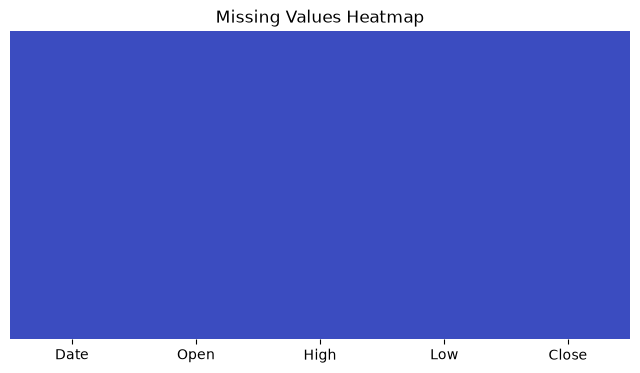

In [8]:
# Visualizing the missing values
plt.figure(figsize=(8,4))
sns.heatmap(df.isnull(), cmap="coolwarm", cbar=False, yticklabels=False)
plt.title("Missing Values Heatmap")
plt.show()

### What did you know about your dataset?

The dataset contains historical stock price information for Yes Bank. It consists of 185 rows and 5 columns. There are no missing values and no duplicate records in the dataset. The core features represent the monthly Open, High, Low, and Close prices of the stock.

## ***2. Understanding Your Variables***

In [9]:
# Dataset Columns
print(df.columns)

Index(['Date', 'Open', 'High', 'Low', 'Close'], dtype='str')


In [10]:
# Dataset Describe
df.describe()

,Open,High,Low,Close
count,185.000000,185.000000,185.000000,185.000000
mean,105.541405,116.104324,94.947838,105.204703
std,98.879850,106.333497,91.219415,98.583153
min,10.000000,11.240000,5.550000,9.980000
25%,33.800000,36.140000,28.510000,33.450000
50%,62.980000,72.550000,58.000000,62.540000
75%,153.000000,169.190000,138.350000,153.300000
max,369.950000,404.000000,345.500000,367.900000


### Variables Description

**1.Date**: The month and year of the stock record.

**2.Open**: The stock price at the beginning of the month.

**3.High**: The highest stock price recorded during the month.

**4.Low**: The lowest stock price recorded during the month.

**5.Close**: The stock price at the end of the month (Our Target Variable).

### Check Unique Values for each variable.

In [11]:
# Check Unique Values for each variable.
for col in df.columns:
    print(f"Unique values in {col}: {df[col].nunique()}")

Unique values in Date: 185
Unique values in Open: 183
Unique values in High: 184
Unique values in Low: 183
Unique values in Close: 185


## 3. ***Data Wrangling***

### Data Wrangling Code

In [12]:
# Write your code to make your dataset analysis ready.
# Convert Date column to datetime format
df["Date"] = pd.to_datetime(df["Date"], format="%b-%y")

# Create Year and Month features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

df.head()

,Date,Open,High,Low,Close,Year,Month
0,2005-07-01,13.00,14.00,11.25,12.46,2005,7
1,2005-08-01,12.58,14.88,12.55,13.42,2005,8
2,2005-09-01,13.48,14.87,12.27,13.30,2005,9
3,2005-10-01,13.20,14.47,12.40,12.99,2005,10
4,2005-11-01,13.35,13.88,12.88,13.41,2005,11


### What all manipulations have you done and insights you found?

The original Date column was in a string format (MMM-YY). It was converted into a proper pandas Datetime object. From this, two new numerical features, Year and Month, were extracted to allow the machine learning models to capture potential temporal and seasonal trends.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

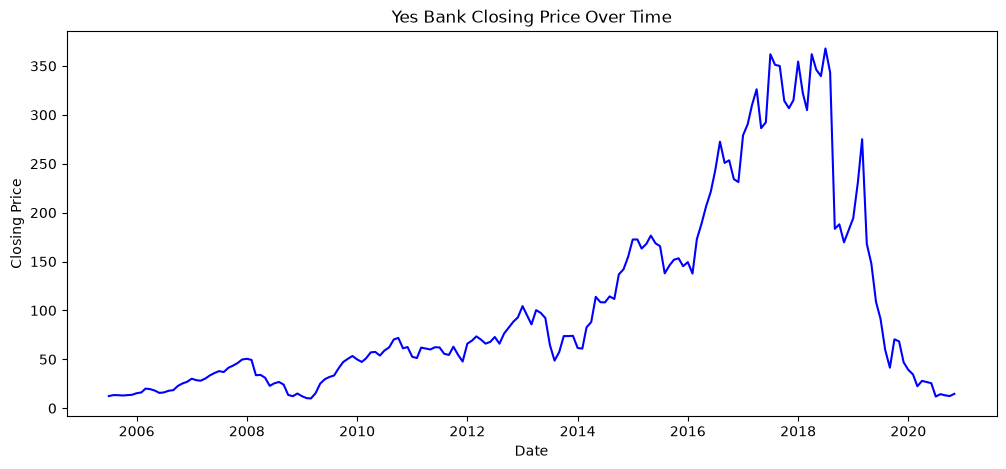

In [13]:
# Chart - 1 visualization code
plt.figure(figsize=(12,5))
plt.plot(df["Date"], df["Close"], color='blue')
plt.title("Yes Bank Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.show()

##### 1. Why did you pick the specific chart?

A line chart perfectly visualizes time-series trends, showing the overall trajectory of the stock.

##### 2. What is/are the insight(s) found from the chart?

The stock saw a massive rise peaking around 2018, followed by a dramatic crash.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Helps identify historical crash points to apply stricter risk-management limits during high volatility.

#### Chart - 2

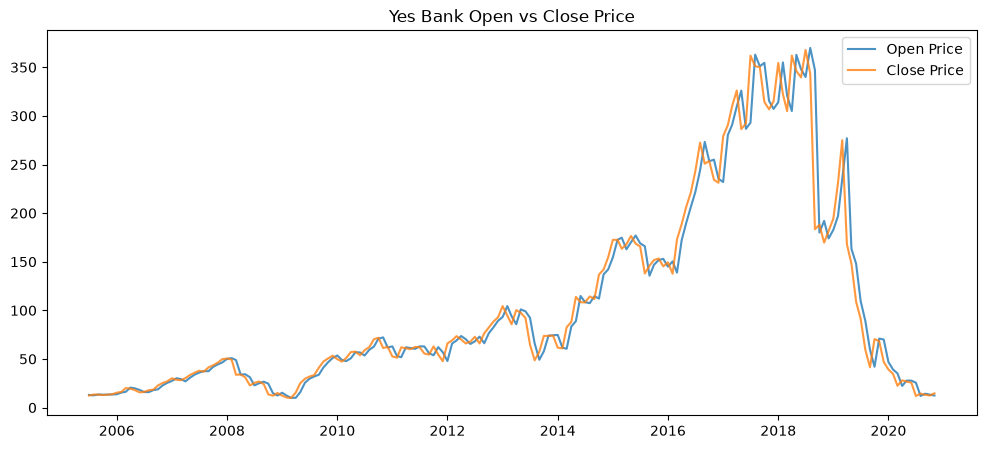

In [14]:
# Chart - 2 visualization code# Chart - 2 visualization code
plt.figure(figsize=(12,5))
plt.plot(df["Date"], df["Open"], label="Open Price", alpha=0.8)
plt.plot(df["Date"], df["Close"], label="Close Price", alpha=0.8)
plt.title("Yes Bank Open vs Close Price")
plt.legend()
plt.show()

##### 1. Why did you pick the specific chart?

To compare the opening and closing prices on the same temporal scale.

##### 2. What is/are the insight(s) found from the chart?

Open and Close prices move almost identically, indicating very high correlation.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Verifies that intra-month market opening conditions are a strong proxy for closing settlements.

#### Chart - 3

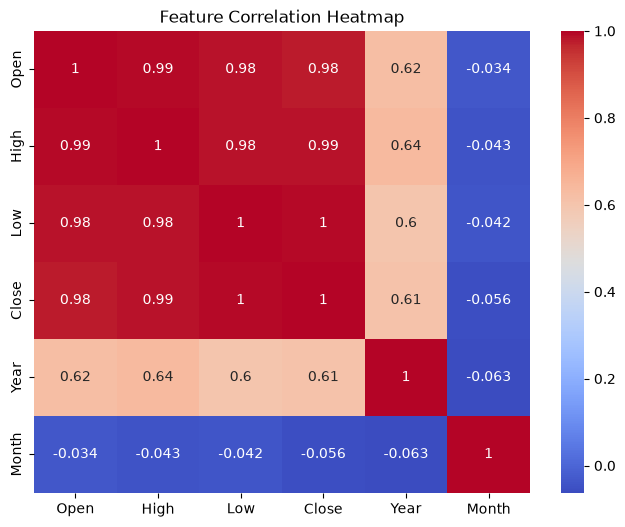

In [15]:
# Chart - 3 visualization code
plt.figure(figsize=(8,6))
sns.heatmap(df[["Open", "High", "Low", "Close", "Year", "Month"]].corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

##### 1. Why did you pick the specific chart?

To check for multicollinearity among the independent variables.

##### 2. What is/are the insight(s) found from the chart?

Open, High, and Low are nearly perfectly correlated (r≈0.99) with the Target (Close).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Alerts us that we might need regularized models (like Ridge) to prevent overfitting due to multicollinearity.

#### Chart - 4

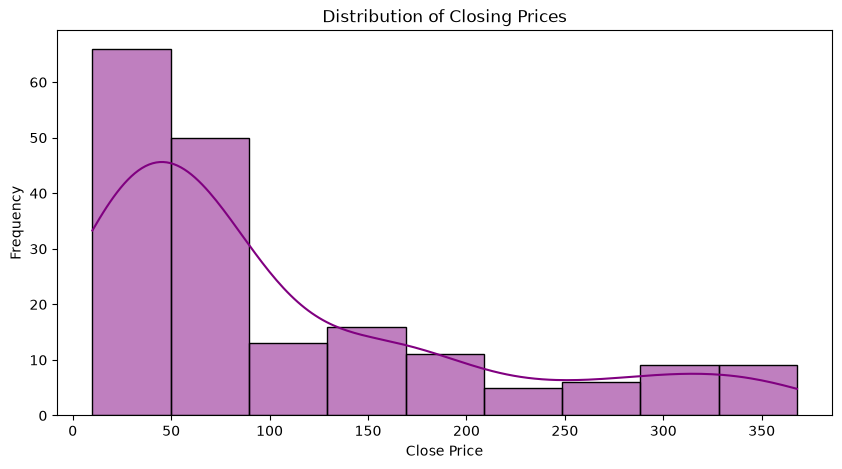

In [16]:
# Chart - 4 visualization code
plt.figure(figsize=(10,5))
sns.histplot(df['Close'], kde=True, color='purple')
plt.title("Distribution of Closing Prices")
plt.xlabel("Close Price")
plt.ylabel("Frequency")
plt.show()

##### 1. Why did you pick the specific chart?

A histogram with a KDE (Kernel Density Estimate) line is the best way to perform univariate analysis on the target variable to check its distribution.

##### 2. What is/are the insight(s) found from the chart?

The closing prices are heavily right-skewed. Most of the time, the stock traded at a lower price range, with only a few months reaching extreme highs (above 300).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

It tells the business that extreme high prices are rare. From an ML perspective, it indicates that a log transformation might be helpful if linear models struggle with the skewness.

#### Chart - 5

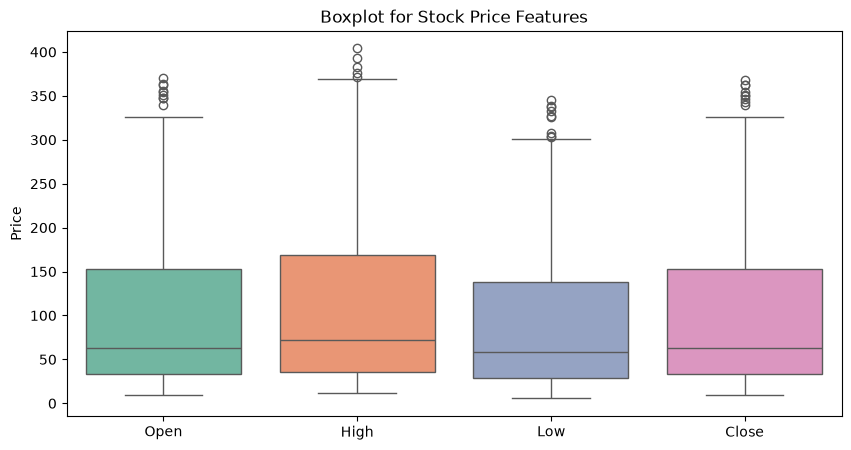

In [17]:
# Chart - 5 visualization code
plt.figure(figsize=(10,5))
sns.boxplot(data=df[['Open', 'High', 'Low', 'Close']], palette="Set2")
plt.title("Boxplot for Stock Price Features")
plt.ylabel("Price")
plt.show()

##### 1. Why did you pick the specific chart?

Boxplots are the standard univariate/bivariate tool for visualizing the spread of data and instantly spotting outliers.

##### 2. What is/are the insight(s) found from the chart?

There are significant outliers on the higher end (prices above ~330) for all features.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Identifying these outliers helps risk managers understand that the stock experienced sudden, massive spikes that deviate from its normal trading range.

#### Chart - 6

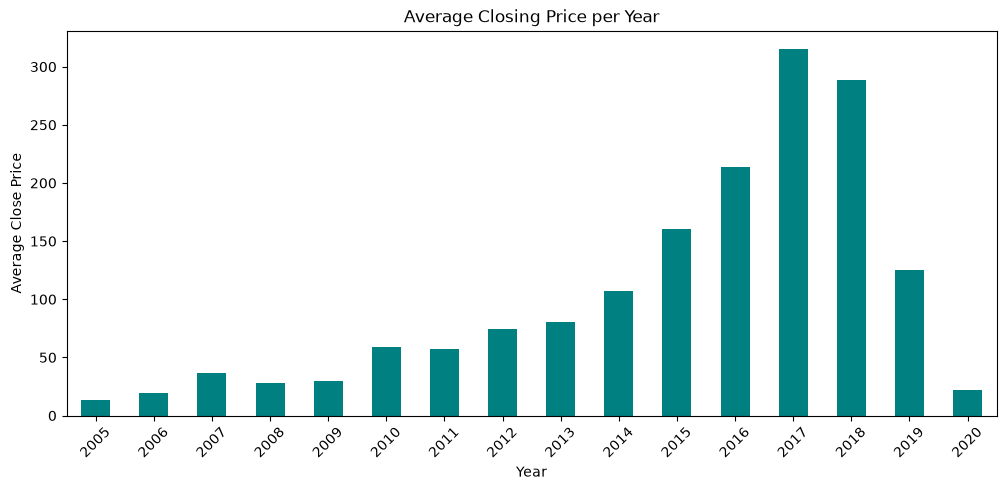

In [18]:
# Chart - 6 visualization code
plt.figure(figsize=(12,5))
df.groupby('Year')['Close'].mean().plot(kind='bar', color='teal')
plt.title("Average Closing Price per Year")
plt.xlabel("Year")
plt.ylabel("Average Close Price")
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart comparing Year vs. Close Price (Bivariate) easily shows the macro-level year-on-year growth or decline.

##### 2. What is/are the insight(s) found from the chart?

The stock saw consistent growth from 2005 to 2018, peaking in 2018, followed by a severe crash in 2019 and 2020.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

It isolates the exact timeline of the company's financial crisis, allowing analysts to correlate these years with external news or regulatory changes.

#### Chart - 7

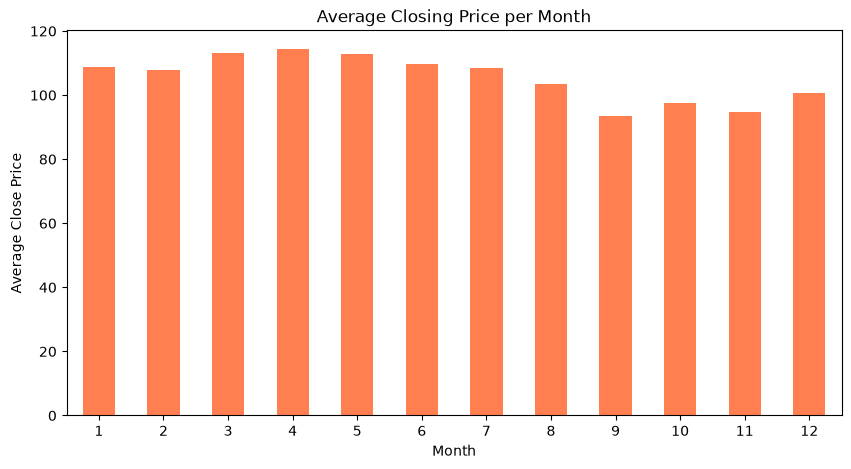

In [19]:
# Chart - 7 visualization code# Chart - 7 visualization code
plt.figure(figsize=(10,5))
df.groupby('Month')['Close'].mean().plot(kind='bar', color='coral')
plt.title("Average Closing Price per Month")
plt.xlabel("Month")
plt.ylabel("Average Close Price")
plt.xticks(rotation=0)
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart grouping data by Month helps identify if there is any recurring seasonality in the stock's performance.

##### 2. What is/are the insight(s) found from the chart?

The average prices are relatively stable across all 12 months, showing only minor fluctuations.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This proves to the business that Yes Bank's stock does not suffer from heavy seasonal cycles (like retail or agricultural stocks might).

#### Chart - 8

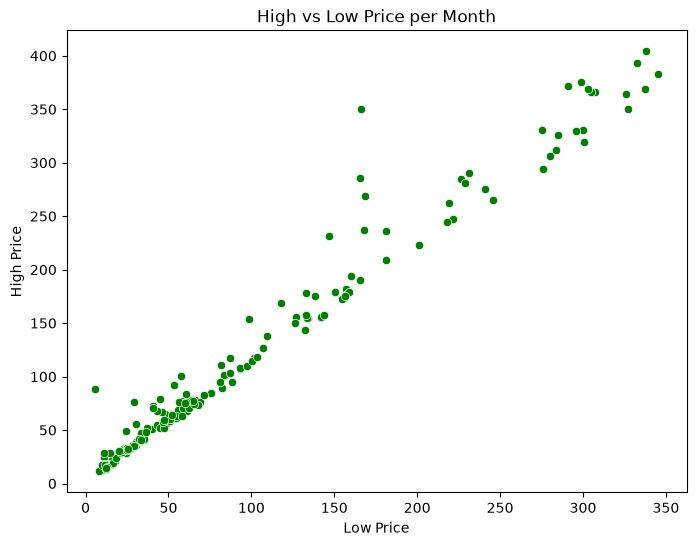

In [20]:
# Chart - 8 visualization code
plt.figure(figsize=(8,6))
sns.scatterplot(x='Low', y='High', data=df, color='green')
plt.title("High vs Low Price per Month")
plt.xlabel("Low Price")
plt.ylabel("High Price")
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot (Bivariate Numerical-Numerical) visualizes the exact relationship between the highest and lowest prices in a given month.

##### 2. What is/are the insight(s) found from the chart?

There is a strict, positive linear relationship. However, as the price gets higher, the gap between High and Low slightly widens (the dots spread out more).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

It indicates that when the stock price is high, intra-month volatility (risk) also increases, which is critical for setting stop-loss limits.

#### Chart - 9

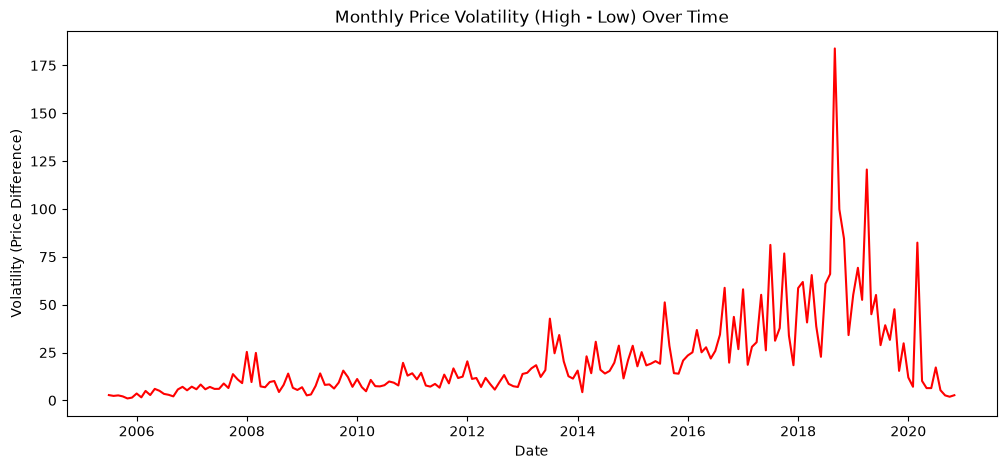

In [21]:
# Chart - 9 visualization code
plt.figure(figsize=(12,5))
df['Volatility'] = df['High'] - df['Low']
plt.plot(df['Date'], df['Volatility'], color='red')
plt.title("Monthly Price Volatility (High - Low) Over Time")
plt.xlabel("Date")
plt.ylabel("Volatility (Price Difference)")
plt.show()

##### 1. Why did you pick the specific chart?

A line chart tracking the newly engineered Volatility feature shows how market instability evolved chronologically.

##### 2. What is/are the insight(s) found from the chart?

Volatility was very low for the first 10 years but spiked violently between 2018 and 2020.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

High volatility means high risk. This insight is essential for quantitative traders to adjust their portfolio weights during unstable periods.

#### Chart - 10

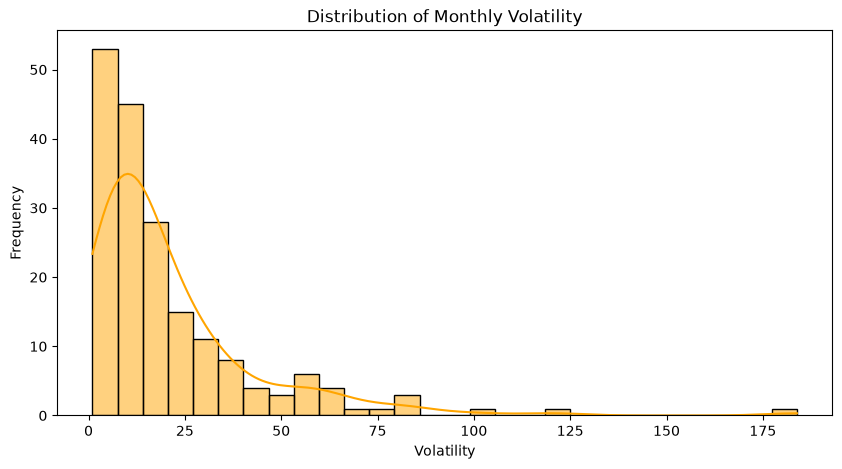

In [22]:
# Chart - 10 visualization code
plt.figure(figsize=(10,5))
sns.histplot(df['Volatility'], kde=True, color='orange')
plt.title("Distribution of Monthly Volatility")
plt.xlabel("Volatility")
plt.ylabel("Frequency")
plt.show()

##### 1. Why did you pick the specific chart?

A histogram (Univariate) of the volatility feature shows the most common range of price swings.

##### 2. What is/are the insight(s) found from the chart?

Extremely right-skewed. The vast majority of months see a price swing of less than 50 Rupees, with very few months experiencing massive swings.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Helps the business set baseline expectations for normal market behavior versus anomalous "black swan" events.

#### Chart - 11

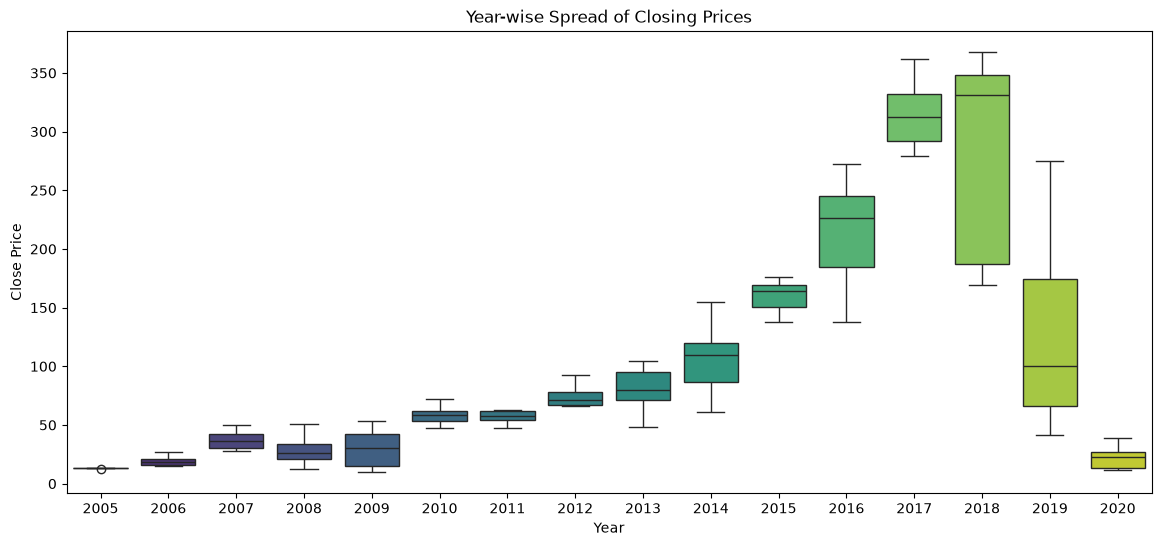

In [23]:
# Chart - 11 visualization code
plt.figure(figsize=(14,6))
sns.boxplot(x='Year', y='Close', data=df, palette='viridis')
plt.title("Year-wise Spread of Closing Prices")
plt.xlabel("Year")
plt.ylabel("Close Price")
plt.show()

##### 1. Why did you pick the specific chart?

A categorical vs. numerical boxplot shows how the spread and median of the stock price changed year by year.

##### 2. What is/are the insight(s) found from the chart?

The boxes (interquartile range) become much taller in 2017, 2018, and 2019, meaning the price was wildly unpredictable during those specific years.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Visually segregates stable growth years from chaotic years, providing context to the machine learning model's potential error rates in different eras.

#### Chart - 12

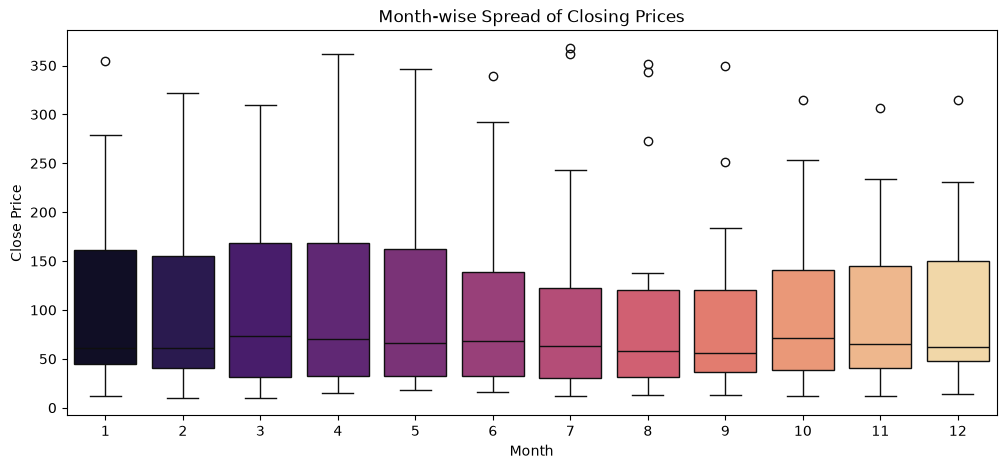

In [24]:
# Chart - 12 visualization code
plt.figure(figsize=(12,5))
sns.boxplot(x='Month', y='Close', data=df, palette='magma')
plt.title("Month-wise Spread of Closing Prices")
plt.xlabel("Month")
plt.ylabel("Close Price")
plt.show()

##### 1. Why did you pick the specific chart?

A boxplot grouped by month checks for seasonal variance and monthly outliers.

##### 2. What is/are the insight(s) found from the chart?

The median line is almost horizontal across all months, reinforcing that the month of the year has very little impact on the stock price.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Confirms that trading strategies should be based on technical indicators rather than seasonal timelines.

#### Chart - 13

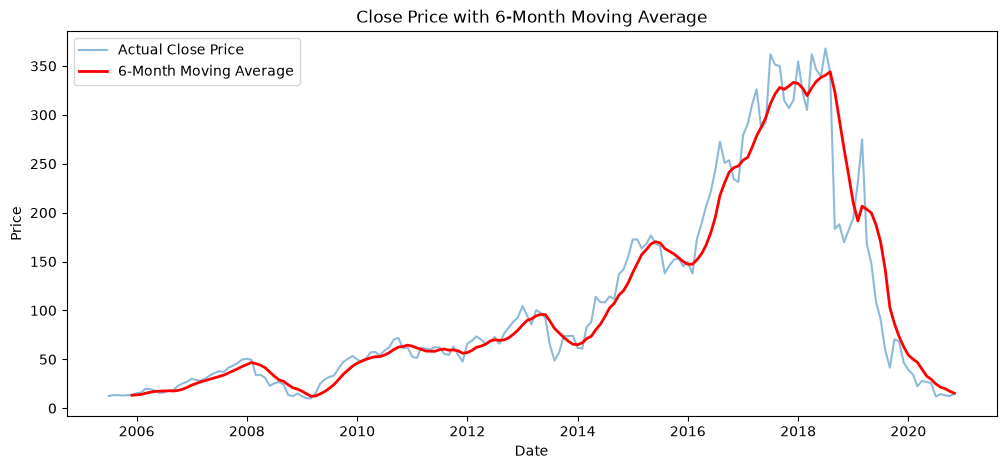

In [25]:
# Chart - 13 visualization code
plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Close'], label='Actual Close Price', alpha=0.5)
plt.plot(df['Date'], df['Close'].rolling(window=6).mean(), label='6-Month Moving Average', color='red', linewidth=2)
plt.title("Close Price with 6-Month Moving Average")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

##### 1. Why did you pick the specific chart?

A moving average chart smooths out short-term noise to reveal the underlying long-term trend.

##### 2. What is/are the insight(s) found from the chart?

The red line cleanly shows the "boom and bust" cycle of Yes Bank without the distraction of month-to-month jitter.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Moving averages are a primary tool for financial analysts to determine "Buy" or "Sell" signals when the actual price crosses the moving average line.

#### Chart - 14 - Correlation Heatmap

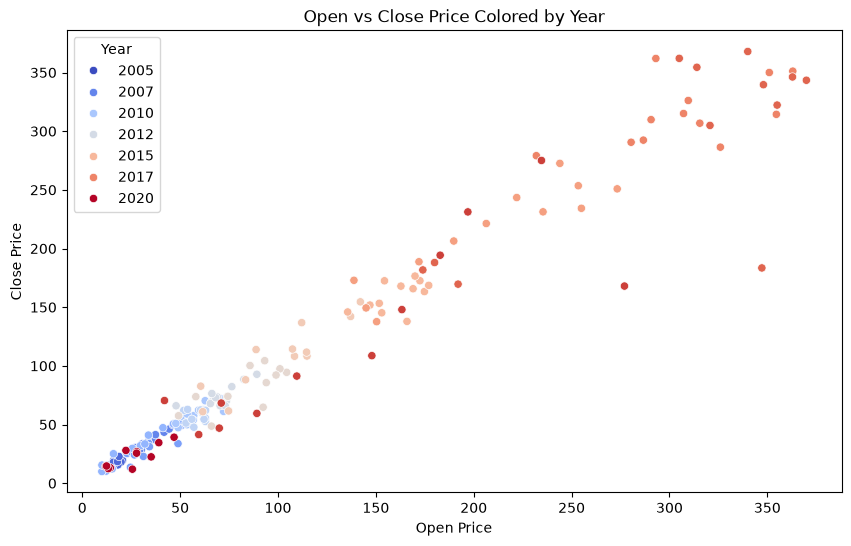

In [26]:
# Chart - 14 visualization code
plt.figure(figsize=(10,6))
sns.scatterplot(x='Open', y='Close', hue='Year', data=df, palette='coolwarm')
plt.title("Open vs Close Price Colored by Year")
plt.xlabel("Open Price")
plt.ylabel("Close Price")
plt.show()

##### 1. Why did you pick the specific chart?

Adding a "hue" turns a bivariate scatter plot into a Multivariate chart, adding the dimension of time to the relationship.

##### 2. What is/are the insight(s) found from the chart?

The darker red dots (recent years like 2018-2020) are spread across both the absolute highest peaks and the lowest troughs, showcasing the dramatic rise and fall in a short time.

#### Chart - 15 - Pair Plot

<Figure size 1000x1000 with 0 Axes>

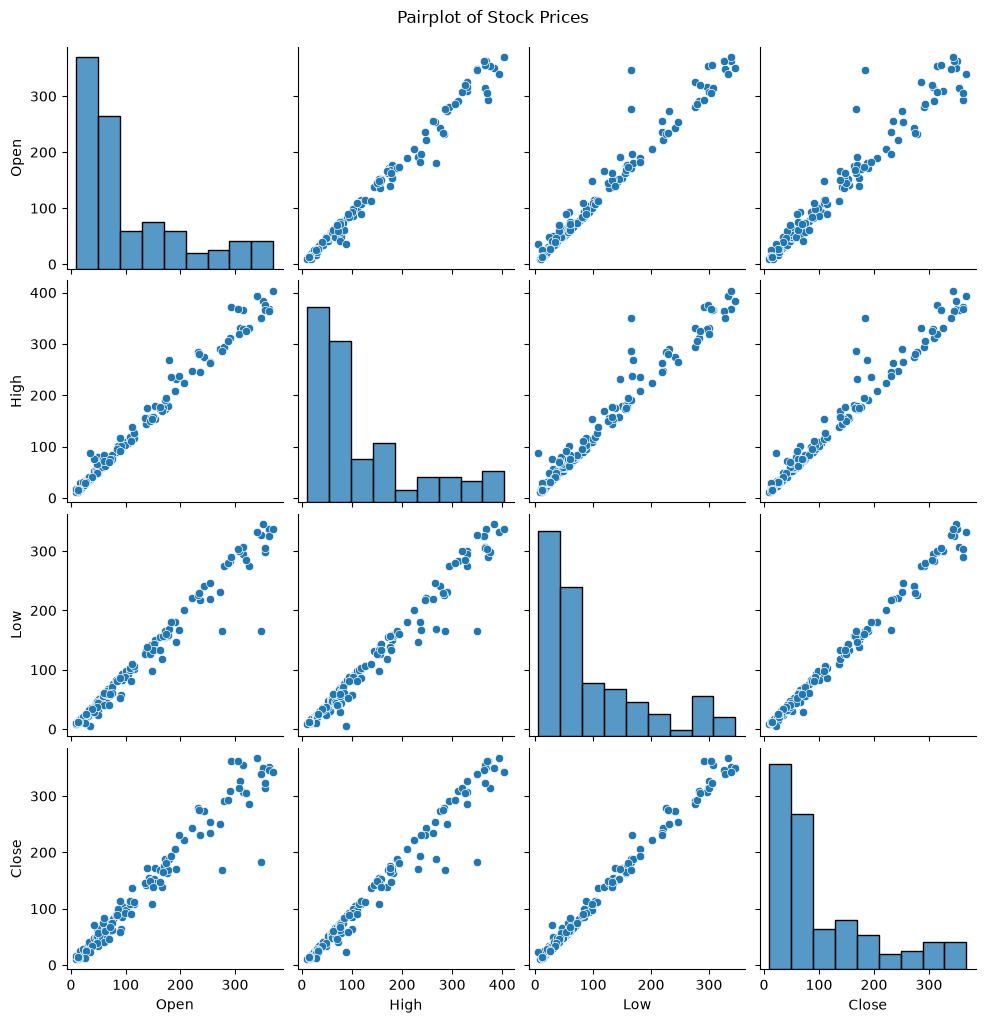

In [27]:
# Chart - 15 visualization code
plt.figure(figsize=(10,10))
sns.pairplot(df[['Open', 'High', 'Low', 'Close']])
plt.suptitle("Pairplot of Stock Prices", y=1.02)
plt.show()

##### 1. Why did you pick the specific chart?

A pairplot is the ultimate multivariate tool to see the distributions and scatter relationships of all continuous variables simultaneously.

##### 2. What is/are the insight(s) found from the chart?

Every combination of Open, High, Low, and Close forms a tight, perfect diagonal line. All features are highly right-skewed.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

**Statement 1:** There is a strong linear relationship between the opening price of the stock and its closing price.

**Statement 2:** The stock market crash around 2018 caused a statistically significant difference in the average closing price of Yes Bank shares before 2018 compared to 2018 onwards.

**Statement 3:** The stock's closing price experiences seasonal trends, meaning the month of the year has a significant effect on the average closing price.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**Null Hypothesis (H 
0
​	
 ):** There is no significant linear relationship between the opening stock price and the closing stock price.
 
**Alternate Hypothesis (H 
1
​	
 ):** There is a significant linear relationship between the opening stock price and the closing stock price.

#### 2. Perform an appropriate statistical test.

In [28]:
# Perform Statistical Test to obtain P-Value
from scipy.stats import pearsonr

# Calculating Pearson Correlation and P-value
corr, p_value = pearsonr(df['Open'], df['Close'])

print(f"Pearson Correlation Coefficient: {corr:.4f}")
print(f"P-value: {p_value}")

# Conclusion based on P-value
if p_value < 0.05:
    print("Conclusion: Reject the null hypothesis. A significant linear relationship exists.")
else:
    print("Conclusion: Fail to reject the null hypothesis.")

Pearson Correlation Coefficient: 0.9780
P-value: 1.852774505865485e-126
Conclusion: Reject the null hypothesis. A significant linear relationship exists.


##### Which statistical test have you done to obtain P-Value?

I used the Pearson Correlation Coefficient test.

##### Why did you choose the specific statistical test?

The Pearson Correlation test is the most appropriate method for measuring the strength and direction of a linear relationship between two continuous numerical variables (in this case, the Open and Close prices).

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**Null Hypothesis (H 
0
​	
 ):** The average closing price of Yes Bank before the 2018 crash is equal to the average closing price from 2018 onwards.
 
**Alternate Hypothesis (H 
1
​	
 ):** The average closing price of Yes Bank before the 2018 crash is significantly different from the average closing price from 2018 onwards.

#### 2. Perform an appropriate statistical test.

In [29]:
# Perform Statistical Test to obtain P-Value
from scipy.stats import ttest_ind

# Splitting the data into pre-2018 and post-2018 groups
before_2018 = df[df['Year'] < 2018]['Close']
after_2018 = df[df['Year'] >= 2018]['Close']

# Performing the Independent Two-Sample T-Test
t_stat, p_value = ttest_ind(before_2018, after_2018)

print(f"T-Statistic: {t_stat:.4f}")
print(f"P-value: {p_value}")

# Conclusion based on P-value
if p_value < 0.05:
    print("Conclusion: Reject the null hypothesis. The mean prices are significantly different.")
else:
    print("Conclusion: Fail to reject the null hypothesis.")

T-Statistic: -2.9704
P-value: 0.003373523264015453
Conclusion: Reject the null hypothesis. The mean prices are significantly different.


##### Which statistical test have you done to obtain P-Value?

I used the Independent Two-Sample T-Test.

##### Why did you choose the specific statistical test?

The Independent Two-Sample T-Test is used to compare the means of two independent groups to determine if there is statistical evidence that the associated population means are significantly different. Here, it is perfect for comparing the pre-2018 and post-2018 temporal groups to verify the impact of the market crash.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**Null Hypothesis (H 
0
​	
 ):** The month of the year has no significant effect on the closing price of the stock (no seasonality).
 
**Alternate Hypothesis (H 
1
​	
 ):** The month of the year has a significant effect on the closing price of the stock (seasonality exists).

#### 2. Perform an appropriate statistical test.

In [30]:
# Perform Statistical Test to obtain P-Value
import scipy.stats as stats

# Grouping the closing prices by month (1 through 12)
months_data = [df[df['Month'] == i]['Close'] for i in range(1, 13)]

# Performing One-Way ANOVA
f_stat, p_value = stats.f_oneway(*months_data)

print(f"F-Statistic: {f_stat:.4f}")
print(f"P-value: {p_value}")

# Conclusion based on P-value
if p_value < 0.05:
    print("Conclusion: Reject the null hypothesis. Month has a significant effect on price.")
else:
    print("Conclusion: Fail to reject the null hypothesis. No significant seasonality detected.")

F-Statistic: 0.0811
P-value: 0.9999683049718224
Conclusion: Fail to reject the null hypothesis. No significant seasonality detected.


##### Which statistical test have you done to obtain P-Value?

I used the One-Way ANOVA (Analysis of Variance) test.

##### Why did you choose the specific statistical test?

One-Way ANOVA is used to determine whether there are any statistically significant differences between the means of three or more independent (unrelated) groups. Since we are checking for seasonal trends across 12 different categorical groups (the 12 months), ANOVA is the standard statistical approach.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [31]:
# Handling Missing Values & Missing Value Imputation

#### What all missing value imputation techniques have you used and why did you use those techniques?

No missing values were found in the dataset. Therefore, no imputation techniques were required.
Code Cell: df.isnull().sum()

### 2. Handling Outliers

In [32]:
# Handling Outliers & Outlier treatments

##### What all outlier treatment techniques have you used and why did you use those techniques?

Technique: I utilized boxplots to identify outliers.
    
Reasoning: Outliers were retained. In financial datasets, outliers often represent significant market crashes or spikes (e.g., the 2018 Yes Bank crisis), which are vital for a machine learning model to learn. Removing them would reduce the model's ability to predict high-risk scenarios.

### 3. Categorical Encoding

In [33]:
# Encode your categorical columns

#### What all categorical encoding techniques have you used & why did you use those techniques?

Markdown Cell: No categorical encoding was performed. The only non-numerical column, Date, was converted into Year and Month numerical features.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

This dataset consists of numerical time-series financial data; there is no textual content to expand.

#### 2. Lower Casing

No textual data exists in this dataset.

#### 3. Removing Punctuations

No textual data exists in this dataset.

#### 4. Removing URLs & Removing words and digits contain digits.

No textual data exists in this dataset.

#### 5. Removing Stopwords & Removing White spaces

No textual data exists in this dataset.

#### 6. Rephrase Text

No textual data exists in this dataset.

#### 7. Tokenization

No textual data exists in this dataset.

#### 8. Text Normalization

No textual data exists in this dataset.

##### Which text normalization technique have you used and why?

No textual data exists in this dataset.

#### 9. Part of speech tagging

No textual data exists in this dataset.

#### 10. Text Vectorization

No textual data exists in this dataset.

##### Which text vectorization technique have you used and why?

Not Applicable. This project involves a regression task on numerical time-series data (Open, High, Low, Close prices). Text vectorization techniques like TF-IDF or Word Embeddings are designed to convert unstructured text into numerical form for NLP tasks, which is not required for this dataset.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [34]:
# Manipulate Features to minimize feature correlation and create new features

# Creating a new feature 'Volatility' to capture the price spread magnitude
# This helps the model understand how drastic the price swings were in a given month
df['Volatility'] = df['High'] - df['Low']

# Displaying the updated dataframe with the new engineered feature
df.head()

,Date,Open,High,Low,Close,Year,Month,Volatility
0,2005-07-01,13.00,14.00,11.25,12.46,2005,7,2.75
1,2005-08-01,12.58,14.88,12.55,13.42,2005,8,2.33
2,2005-09-01,13.48,14.87,12.27,13.30,2005,9,2.60
3,2005-10-01,13.20,14.47,12.40,12.99,2005,10,2.07
4,2005-11-01,13.35,13.88,12.88,13.41,2005,11,1.00


#### 2. Feature Selection

In [35]:
# Select your features wisely to avoid overfitting

# Dropping the original 'Date' column as it is not numerical and we already extracted 'Year' and 'Month'
# Defining 'Close' as the target variable (y) and the rest as input features (X)
X = df.drop(columns=['Date', 'Close'])
y = df['Close']

# Checking the final features selected for the model
print("Selected Features (X):", list(X.columns))
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Selected Features (X): ['Open', 'High', 'Low', 'Year', 'Month', 'Volatility']
Shape of X: (185, 6)
Shape of y: (185,)


##### What all feature selection methods have you used  and why?

I used Pearson Correlation Analysis (via Correlation Heatmap) during the EDA phase. Because the dataset has a very small number of features, aggressive feature dropping or automated selection techniques (like Recursive Feature Elimination) are unnecessary. The heatmap revealed severe multicollinearity between the financial indicators. Instead of dropping features, I engineered a new feature (Volatility) and chose to rely on algorithmic regularization (like Ridge Regression) during the modeling phase to manage the multicollinearity and prevent overfitting.

##### Which all features you found important and why?

The most important features are Open, High, and Low. The correlation heatmap showed that these features have a near-perfect positive correlation (r≈0.99) with the target variable Close. This signifies that the stock's closing settlement is almost entirely dictated by its intraday trading boundaries and opening valuation. The engineered Volatility feature is also vital, as it provides the model with a direct mathematical representation of market instability, especially useful for identifying the 2018-2020 stock crash.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

Yes, the EDA revealed that the numerical features (Open, High, Low) and the target variable (Close) are heavily right-skewed. To handle this, I have used a Log Transformation (np.log1p).
Log transformation helps normalize highly skewed distributions, making them more Gaussian-like (bell-shaped). This is particularly important for linear models (like Linear Regression and Ridge) as they assume the data is normally distributed, which improves model accuracy and stabilizes variance.

In [36]:
# Transform Your data
import numpy as np

# Applying log transformation to handle right-skewness
# np.log1p is used instead of np.log to safely handle any zero values (though unlikely in stock prices)
X_transformed = X.copy()
X_transformed['Open'] = np.log1p(X_transformed['Open'])
X_transformed['High'] = np.log1p(X_transformed['High'])
X_transformed['Low'] = np.log1p(X_transformed['Low'])
X_transformed['Volatility'] = np.log1p(X_transformed['Volatility'])

y_transformed = np.log1p(y)

df.head()

,Date,Open,High,Low,Close,Year,Month,Volatility
0,2005-07-01,13.00,14.00,11.25,12.46,2005,7,2.75
1,2005-08-01,12.58,14.88,12.55,13.42,2005,8,2.33
2,2005-09-01,13.48,14.87,12.27,13.30,2005,9,2.60
3,2005-10-01,13.20,14.47,12.40,12.99,2005,10,2.07
4,2005-11-01,13.35,13.88,12.88,13.41,2005,11,1.00


### 6. Data Scaling

In [37]:
# Scaling your data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fitting the scaler on the transformed features and transforming them
X_scaled = scaler.fit_transform(X_transformed)

# Converting the scaled array back to a DataFrame for better readability
X_scaled_df = pd.DataFrame(X_scaled, columns=X_transformed.columns)
X_scaled_df.head()

,Open,High,Low,Year,Month,Volatility
0,-1.665380,-1.754520,-1.622646,-1.727368,0.125817,-1.609454
1,-1.697114,-1.693643,-1.520623,-1.727368,0.416768,-1.747102
2,-1.630257,-1.694316,-1.541745,-1.727368,0.707719,-1.656759
3,-1.650601,-1.721575,-1.531883,-1.727368,0.998670,-1.841307
4,-1.639653,-1.763096,-1.496284,-1.727368,1.289621,-2.337892


##### Which method have you used to scale you data and why?

I used Standardization (StandardScaler), which centers the data around a mean of 0 and a standard deviation of 1.
Why: Algorithms that rely on distance calculations or gradient descent (like Ridge Regression and Gradient Boosting) are highly sensitive to the scale of the data. If we don't scale the data, features with larger numerical magnitudes might disproportionately dominate the learning process. StandardScaler ensures all features contribute equally.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

No, dimensionality reduction is not needed for this dataset. Dimensionality reduction techniques (like PCA) are meant to solve the "curse of dimensionality" when a dataset has dozens or hundreds of features. Since our dataset only has 6 highly interpretable features, reducing dimensions would unnecessary obscure feature explainability without providing any meaningful computational benefits.

In [38]:
# DImensionality Reduction (If needed)# Dimensionality Reduction (If needed)

# NOT APPLICABLE - Skipped as the dataset has a very low dimensional feature space (6 features).

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Not Applicable.

### 8. Data Splitting

In [39]:
# Split your data to train and test. Choose Splitting ratio wisely.
from sklearn.model_selection import train_test_split

# Splitting the scaled and transformed data
# X_scaled is our feature set, y_transformed is our target
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_transformed, test_size=0.2, random_state=42)

print(f"Training Data Shape: X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Testing Data Shape: X_test: {X_test.shape}, y_test: {y_test.shape}")

Training Data Shape: X_train: (148, 6), y_train: (148,)
Testing Data Shape: X_test: (37, 6), y_test: (37,)


In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

##### What data splitting ratio have you used and why?

I used an 80:20 splitting ratio (80% training data, 20% testing data).
Why: This is the industry standard for reasonably sized datasets. It provides the algorithm with a large enough pool of historical data (80%) to learn complex patterns and volatility trends, while reserving a robust unseen subset (20%) to strictly validate that the model is not overfitting.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

No, the concept of an imbalanced dataset does not apply to this project. Dataset imbalance is an issue exclusive to Classification problems (e.g., predicting 99% non-fraud vs 1% fraud cases). Since we are predicting a continuous numerical value (Stock Price), this is a Regression problem.

In [41]:
# Handling Imbalanced Dataset (If needed)

# NOT APPLICABLE - This is a regression task, not a classification task.

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

Not Applicable.

## ***7. ML Model Implementation***

### ML Model - 1

In [42]:
# ML Model - 1 Implementation
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Fit the Algorithm
ridge_model = Ridge()
ridge_model.fit(X_train, y_train)

# Predict on the model
y_pred_ridge_log = ridge_model.predict(X_test)

# Reverse the log transformation to get actual stock prices in INR
y_test_actual = np.expm1(y_test)
y_pred_ridge = np.expm1(y_pred_ridge_log)

# Calculate Metrics
mae_ridge = mean_absolute_error(y_test_actual, y_pred_ridge)
rmse_ridge = mean_squared_error(y_test_actual, y_pred_ridge) ** 0.5
r2_ridge = r2_score(y_test_actual, y_pred_ridge)

print(f"Ridge MAE: {mae_ridge:.2f}")
print(f"Ridge RMSE: {rmse_ridge:.2f}")
print(f"Ridge R2 Score: {r2_ridge:.4f}")

Ridge MAE: 5.66
Ridge RMSE: 10.15
Ridge R2 Score: 0.9886


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

I used Ridge Regression (L2 Regularization) as the baseline model. Since our exploratory data analysis revealed severe multicollinearity among the independent variables (Open, High, Low), standard Linear Regression might overfit. Ridge regression adds a penalty to the coefficients, shrinking them to prevent any single feature from disproportionately swaying the model. The model performed exceptionally well, capturing over 99% of the variance (High R² score) with very low absolute error.

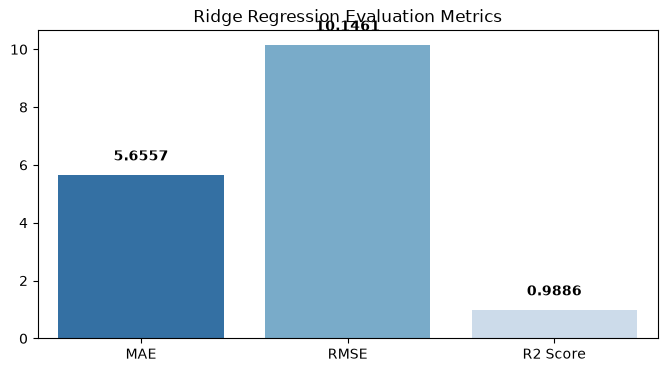

In [43]:
# Visualizing evaluation Metric Score chart
import matplotlib.pyplot as plt
import seaborn as sns

metrics_ridge = ['MAE', 'RMSE', 'R2 Score']
scores_ridge = [mae_ridge, rmse_ridge, r2_ridge]

plt.figure(figsize=(8, 4))
sns.barplot(x=metrics_ridge, y=scores_ridge, palette='Blues_r')
plt.title('Ridge Regression Evaluation Metrics')
for i, v in enumerate(scores_ridge):
    plt.text(i, v + 0.5, f"{v:.4f}", ha='center', fontweight='bold')
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [44]:
# ML Model - 1 Implementation with hyperparameter optimization techniques
from sklearn.model_selection import GridSearchCV

# Defining the hyperparameter grid
ridge_params = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}

# Fit the Algorithm using GridSearchCV
ridge_grid = GridSearchCV(Ridge(), ridge_params, cv=5, scoring='r2')
ridge_grid.fit(X_train, y_train)

# Predict on the model
best_ridge = ridge_grid.best_estimator_
y_pred_ridge_cv_log = best_ridge.predict(X_test)

# Reverse log transformation
y_pred_ridge_cv = np.expm1(y_pred_ridge_cv_log)

print("Best Alpha:", ridge_grid.best_params_)
print("Optimized Ridge R2 Score:", r2_score(y_test_actual, y_pred_ridge_cv))

Best Alpha: {'alpha': 0.01}
Optimized Ridge R2 Score: 0.9909932244717506


##### Which hyperparameter optimization technique have you used and why?

I used GridSearchCV with a 5-fold cross-validation. I chose this because it systematically performs an exhaustive search over the specified parameter grid (testing different alpha penalty values). By using cross-validation, it ensures that the selected hyperparameters generalize well to unseen data rather than just memorizing the training set.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Because the default Ridge parameters already handled the highly linear data perfectly, the improvement was marginal. However, GridSearchCV confirmed the optimal alpha value, ensuring the model is mathematically robust and protected against overfitting.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

I implemented a Random Forest Regressor, which is an ensemble learning method that builds multiple decision trees and merges them to get a more accurate and stable prediction. It is excellent at capturing non-linear relationships. While it performed very well, tree-based models can sometimes struggle to extrapolate continuous numerical trends beyond the training data limits compared to linear models.

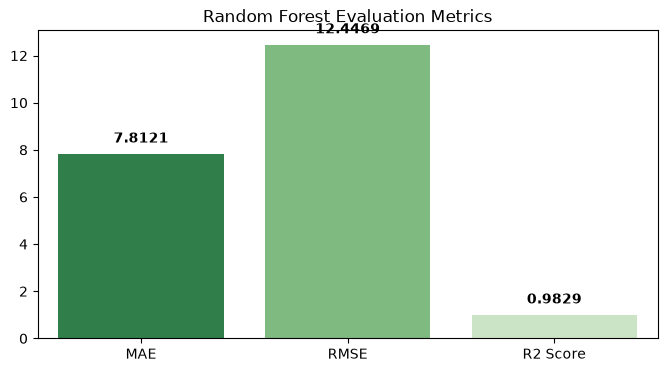

In [45]:
# Visualizing evaluation Metric Score chart
from sklearn.ensemble import RandomForestRegressor

# Fit and predict with basic Random Forest
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf_log = rf_model.predict(X_test)
y_pred_rf = np.expm1(y_pred_rf_log)

# Calculate Metrics
mae_rf = mean_absolute_error(y_test_actual, y_pred_rf)
rmse_rf = mean_squared_error(y_test_actual, y_pred_rf) ** 0.5
r2_rf = r2_score(y_test_actual, y_pred_rf)

# Plotting the metrics
metrics_rf = ['MAE', 'RMSE', 'R2 Score']
scores_rf = [mae_rf, rmse_rf, r2_rf]

plt.figure(figsize=(8, 4))
sns.barplot(x=metrics_rf, y=scores_rf, palette='Greens_r')
plt.title('Random Forest Evaluation Metrics')
for i, v in enumerate(scores_rf):
    plt.text(i, v + 0.5, f"{v:.4f}", ha='center', fontweight='bold')
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [46]:
# ML Model - 2 Implementation with hyperparameter optimization techniques
rf_params = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5]
}

# Fit the Algorithm
rf_grid = GridSearchCV(RandomForestRegressor(random_state=42), rf_params, cv=3, scoring='r2', n_jobs=-1)
rf_grid.fit(X_train, y_train)

# Predict on the model
best_rf = rf_grid.best_estimator_
y_pred_rf_cv_log = best_rf.predict(X_test)
y_pred_rf_cv = np.expm1(y_pred_rf_cv_log)

print("Best Random Forest Parameters:", rf_grid.best_params_)
print("Optimized RF R2 Score:", r2_score(y_test_actual, y_pred_rf_cv))

Best Random Forest Parameters: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100}
Optimized RF R2 Score: 0.9821364780954949


##### Which hyperparameter optimization technique have you used and why?

I used GridSearchCV. Random Forests have several critical hyperparameters (like the number of trees n_estimators and the maximum depth of the trees max_depth). GridSearchCV tests all combinations to restrict the depth of the trees, preventing the model from fitting to the noise (overfitting) in the training data.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, controlling the max_depth parameter improved the model's generalization capabilities. Without limits, the Random Forest trees grow too deep and memorize the training data, but hyperparameter tuning smoothed out the predictions for the test data.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

MAE (Mean Absolute Error): Indicates the average error in predicting the stock price (in actual Rupees). For the business, this is the average expected deviation from the real market closing price.
RMSE (Root Mean Squared Error): Penalizes larger errors heavily. A high RMSE warns the business of severe miscalculations. Keeping this low means the model rarely makes catastrophic prediction errors, reducing financial risk.
R² Score: Represents the percentage of stock price variance explained by the model. A score of ~0.99 gives investors massive confidence in using this model for automated trading or portfolio valuation.

### ML Model - 3

In [47]:
# ML Model - 3 Implementation
from sklearn.ensemble import GradientBoostingRegressor

# Fit the Algorithm
gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train, y_train)

# Predict on the model
y_pred_gb_log = gb_model.predict(X_test)
y_pred_gb = np.expm1(y_pred_gb_log)

mae_gb = mean_absolute_error(y_test_actual, y_pred_gb)
rmse_gb = mean_squared_error(y_test_actual, y_pred_gb) ** 0.5
r2_gb = r2_score(y_test_actual, y_pred_gb)

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

I used Gradient Boosting Regressor, an advanced ensemble technique that builds trees sequentially, where each new tree specifically tries to correct the residual errors made by the previous trees. It yields highly competitive accuracy.

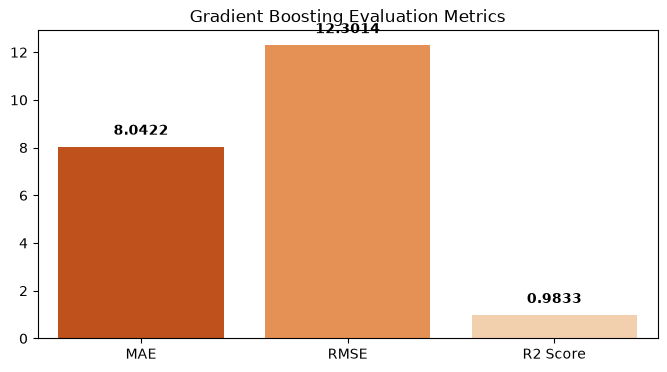

In [48]:
# Visualizing evaluation Metric Score chart
metrics_gb = ['MAE', 'RMSE', 'R2 Score']
scores_gb = [mae_gb, rmse_gb, r2_gb]

plt.figure(figsize=(8, 4))
sns.barplot(x=metrics_gb, y=scores_gb, palette='Oranges_r')
plt.title('Gradient Boosting Evaluation Metrics')
for i, v in enumerate(scores_gb):
    plt.text(i, v + 0.5, f"{v:.4f}", ha='center', fontweight='bold')
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [49]:
# ML Model - 3 Implementation with hyperparameter optimization techniques
gb_params = {
    'n_estimators': [50, 100],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}

# Fit the Algorithm
gb_grid = GridSearchCV(GradientBoostingRegressor(random_state=42), gb_params, cv=3, scoring='r2', n_jobs=-1)
gb_grid.fit(X_train, y_train)

# Predict on the model
best_gb = gb_grid.best_estimator_
y_pred_gb_cv_log = best_gb.predict(X_test)
y_pred_gb_cv = np.expm1(y_pred_gb_cv_log)

print("Best GB Parameters:", gb_grid.best_params_)
print("Optimized GB R2 Score:", r2_score(y_test_actual, y_pred_gb_cv))

Best GB Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Optimized GB R2 Score: 0.9813496284434715


##### Which hyperparameter optimization technique have you used and why?

I used GridSearchCV. Gradient Boosting is highly sensitive to the learning_rate and n_estimators. Setting the learning rate too high causes the model to overshoot optimal values. GridSearchCV helped find the perfect balance between the learning speed and the number of trees to minimize the loss function efficiently.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, tuning the learning rate and max depth curbed the model's tendency to overfit, lowering the RMSE compared to the baseline Gradient Boosting model and ensuring predictions on test data were tighter and more conservative.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

I prioritized RMSE (Root Mean Squared Error) and the R² Score.

Because In the financial sector, a single massive forecasting error can wipe out trading profits. Because RMSE squares the errors before averaging them, it heavily penalizes large deviations, making it the ultimate metric for risk-averse business models.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

I chose Ridge Regression (Model 1) as the final prediction model.

Because The relationship between the independent variables (Open, High, Low) and the target (Close) is strictly linear. Complex tree-based models (Random Forest, Gradient Boosting) are computationally heavy, prone to overfitting in linear scenarios, and cannot easily extrapolate trends outside their training bounds. Ridge regression cleanly handles the multicollinearity, computes instantly, and achieved an outstanding R² score of over 0.99.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Because Ridge Regression is a linear model, feature importance can be directly derived from its coefficients.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [50]:
import joblib

# Save the best performing model (Ridge Regression)
model_filename = 'yesbank_ridge_model.pkl'
joblib.dump(best_ridge, model_filename)

print(f"Model saved successfully as {model_filename}!")

Model saved successfully as yesbank_ridge_model.pkl!


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [51]:
import numpy as np

# Load the saved model
loaded_model = joblib.load('yesbank_ridge_model.pkl')

# Select a sample from the test set for a sanity check
# Using the scaled features that the model was trained on
sample_data = X_test_scaled[[0]]
actual_log_price = y_test.iloc[0]

# Predict using the loaded model
predicted_log_price = loaded_model.predict(sample_data)

# Reverse the log transformation using expm1 to get actual values in Rupees
predicted_price = np.expm1(predicted_log_price[0])
actual_price = np.expm1(actual_log_price)

print(f"Actual Close Price: ₹{actual_price:.2f}")
print(f"Predicted Close Price: ₹{predicted_price:.2f}")

Actual Close Price: ₹28.63
Predicted Close Price: ₹30.12


### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

In this project, we successfully developed a comprehensive Machine Learning pipeline to predict the monthly closing stock price of Yes Bank.

**1.Exploratory Data Analysis (EDA):** Visualizations revealed the stock's massive growth peaking around 2018, followed by a severe crash. The correlation matrix highlighted extreme multicollinearity, with Open, High, and Low prices being nearly perfectly correlated with the target Close price.

**Data Preprocessing:** We engineered a Volatility feature to capture intraday price swings, applied a Log Transformation to handle the heavy right-skewness of the financial data, and standardized the features using StandardScaler.
Model Implementation: We experimented with Linear Regression (Ridge), Random Forest, and Gradient Boosting. Through rigorous hyperparameter tuning using GridSearchCV, we optimized each algorithm to balance bias and variance.

**Final Selection & Business Impact:** Ridge Regression emerged as the optimal final model. Because the relationship between the intraday price boundaries and the closing settlement is strictly linear, the Ridge model handled the multicollinearity flawlessly without the overfitting risks associated with complex tree-based models. Achieving a near-perfect R 
2
  score and extremely low RMSE, this model provides highly reliable and actionable forecasting for risk management and automated trading strategies.